In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../../temporal_context/config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries
from useful_stuff.general_utils.regression import linear_encoding, dyn_linear_encoding


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0' 
    date: str = '250313'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    folder_name: str = "talia_20each_tizi" #"fewer_occlusion" #
cfg = Cfg()

# Load the data

In [3]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [4]:
ba_raster = TimeSeries(raster.get_array()[:15, :, :], fs=cfg.new_fs)

In [5]:
from image_processing.computational_models import map_image_order_from_ann_to_monkey
from torchvision.datasets import ImageFolder
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; cfg.layer_name = 'blocks.16.mlp.fc2'
dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"), 
    allow_empty=True, 
)
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)
feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]
features = features[:, idx_ord]

# Linear encoding (repeated for each timepoint)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model = linear_encoding('ridge', 'kf', score_type="r2")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_r2 = []
for i in range(t_pts):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = None
    counter = 0
    score = model.crossvalidate(X, Y)
    time_score_r2.append(score)


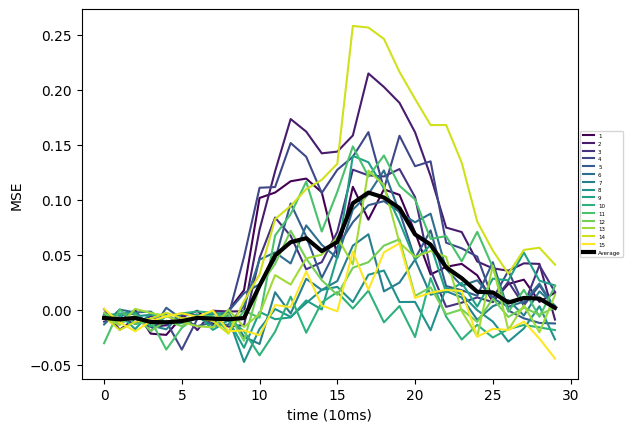

<Figure size 640x480 with 0 Axes>

In [9]:
if type(time_score_r2)== list: time_score_r2 = np.stack(time_score_r2, axis=-1)
for i, c in enumerate(colors):
    plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(time_score_r2, axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [10]:
import matplotlib.pyplot as plt
import numpy as np

model = linear_encoding('ridge', 'kf', score_type="corr")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_corr = []
for i in range(t_pts):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = model.crossvalidate(X, Y)
    time_score_corr.append(score)


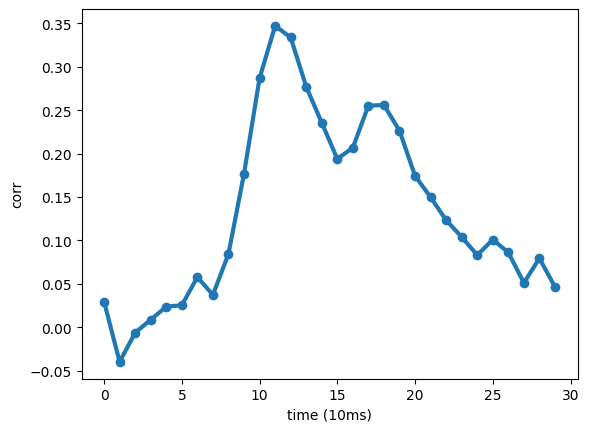

<Figure size 640x480 with 0 Axes>

In [11]:
if type(time_score_corr) == list: time_score_corr = np.stack(time_score_corr, axis=-1)
plt.plot(time_score_corr, "-o", linewidth=3)
# plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("corr")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

# Static dynamic linear encoding

In [13]:
model = dyn_linear_encoding('ridge', 'kf', None, score_type="r2")
s = model.crossvalidate_static_dyn(features, ba_raster) #TimeSeries(ba_raster[:10], ba_raster.get_fs()))

In [15]:
model = dyn_linear_encoding('ridge', 'kf', score_type="r2", max_lag=None)
model.fit_static_dyn(features[:,:100], TimeSeries(ba_raster.get_array()[:,:30, :100], ba_raster.get_fs()))
p = model.predict_static_dyn(features[:,:20], transpose=True)
# fix transpose in predict
# do predict in general dyn

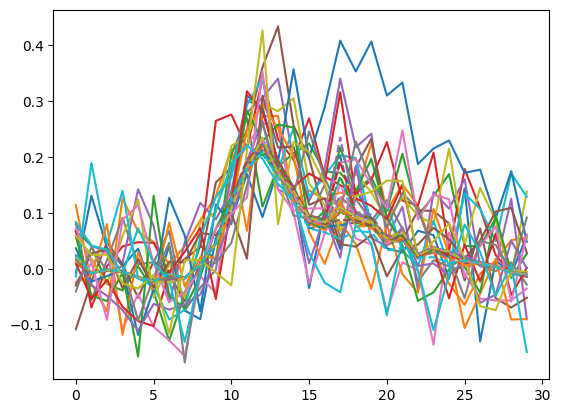

In [16]:
p_arr = np.stack(p.get_array(), axis=1)
plt.plot(np.mean(ba_raster.get_array()[:,:30,:20], axis=0));
plt.plot(np.mean(p_arr, axis=0), linestyle="--");

In [29]:
model = dyn_linear_encoding('ridge', 'kf', None, score_type="r2")
s = model.crossvalidate_static_dyn(features, ba_raster) #TimeSeries(ba_raster[:10], ba_raster.get_fs()))

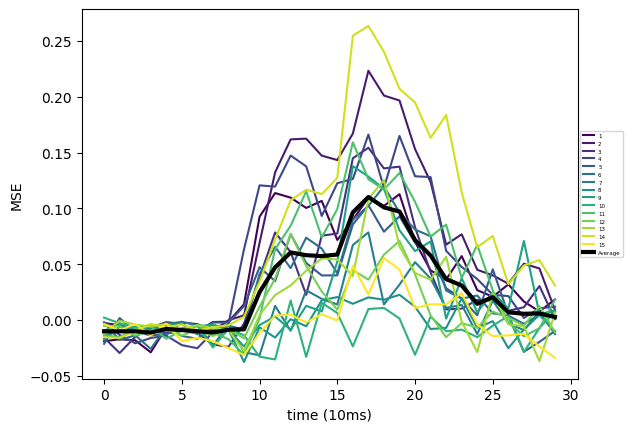

<Figure size 640x480 with 0 Axes>

In [38]:
colors = cmap(np.linspace(0, 1, s.get_array().shape[0]))
for i, c in enumerate(colors):
    plt.plot(s.get_array()[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(s.get_array(), axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [ ]:
model = dyn_linear_encoding('ridge', 'kf', score_type="corr")
s = model.crossvalidate_static_dyn_linear_encoding(features, ba_raster) #TimeSeries(ba_raster[:10], ba_raster.get_fs()))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


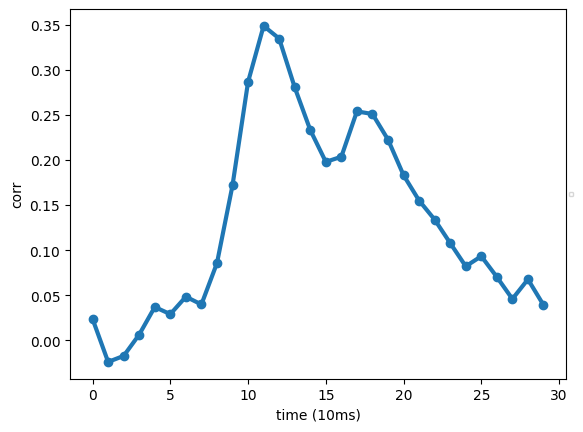

<Figure size 640x480 with 0 Axes>

In [28]:
plt.plot(s.get_array().T, "-o", linewidth=3)
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("corr")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

# time-general dynamic linear encoding

In [18]:
model = dyn_linear_encoding('ridge', 'kf', 10, score_type="r2", symmetric=True)
model.fit_general_dyn(TimeSeries(ba_raster.get_array()[:,:40, :-100], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:,:40, :-100], ba_raster.get_fs()))
p = model.predict_general_dyn(ba_raster.get_array()[:,15, -100:])
s = model.score_general_dyn(TimeSeries(ba_raster.get_array()[:,:30, -100:], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:,:30, -100:], ba_raster.get_fs()))

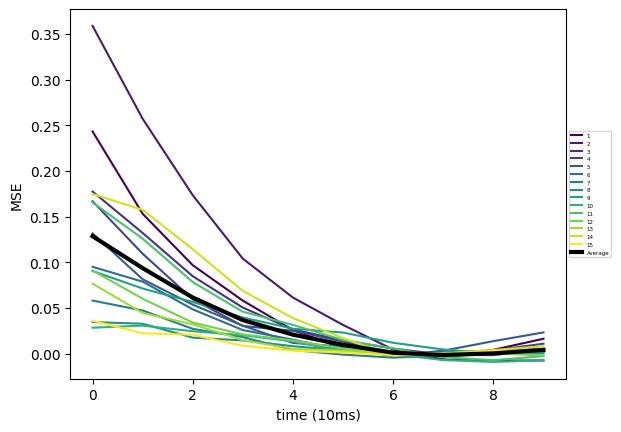

<Figure size 640x480 with 0 Axes>

In [19]:
cmap = plt.cm.viridis
t_pts = len(s)
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
for i, c in enumerate(colors):
    plt.plot(s.get_array().T[1:, i], color=c, label=f"{i+1}");
    # plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(s.get_array()[:,1:], axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [20]:
model = dyn_linear_encoding('ridge', 'kf', 10, score_type="r2", symmetric=True)
# model.fit_general_dyn(TimeSeries(ba_raster.get_array()[:,:40, :4000], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:,:40, :4000], ba_raster.get_fs()))
s = model.crossvalidate_general_dyn(TimeSeries(ba_raster.get_array()[:25,:20, :], ba_raster.get_fs()), TimeSeries(ba_raster.get_array()[:25,:20, :], ba_raster.get_fs()))

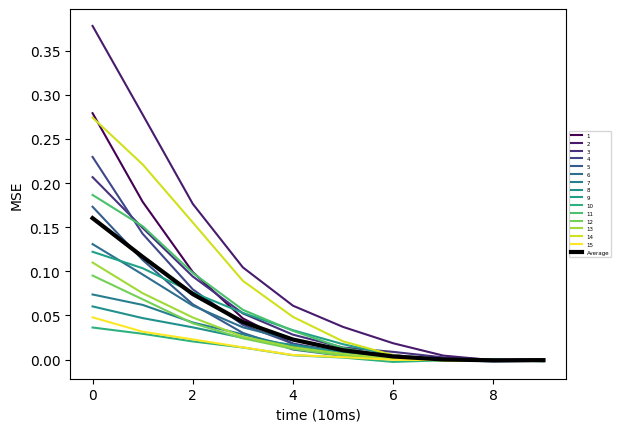

<Figure size 640x480 with 0 Axes>

In [21]:
cmap = plt.cm.viridis
t_pts = len(s)
colors = cmap(np.linspace(0, 1, s.get_array().shape[0]))
for i, c in enumerate(colors):
    plt.plot(s.get_array().T[1:, i], color=c, label=f"{i+1}");
    # plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(s.get_array()[:,1:], axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

# TODO 
- function to run (get weights, scores and crossvalidate) general dyn linear encoding
- function to run (get weights, scores and crossvalidate) time specific dyn linear encoding
- function to stack 4th dim of data when we have multiple reps (treat them as datapoints of a noisy measure)